# MP2: Control task in a continuous environment

In [3]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import random


from environments.acrobot_gym import Acrobot

In [4]:
env = Acrobot()

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


## Simulation and plotting functions

In [5]:
class AbstractAgent:
    """
    Abstract base class for agents interacting with the FrozenLake environment.
    Each agent must implement the `observe` method to update its internal state based on the observed transition,
    and the `act` method to choose an action given the current state.
    """
    def __init__(self, env: Acrobot):
        self.env = env

    def observe(self, state, action, reward, next_state, done):
        raise NotImplementedError

    def act(self, state):
        raise NotImplementedError
    

def run_agent(env: Acrobot, agent: AbstractAgent, num_episodes: int, print_every: int = 10):
    """
    Run the given agent in the environment for a specified number of episodes and collect statistics.
    """
    rewards = []
    episode_length = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        steps = 0
        episode_reward = 0

        while not done:
            action = agent.act(state) # TODO
            next_state, reward = env.do_action(action)
            done = env.end
            steps += 1
            # TODO: update agent with the observed transition
            agent.observe(state, action, reward, next_state, done) 
            episode_reward += reward
            state = next_state
        
        # TODO: log rewards and episode length
        rewards.append(episode_reward)
        episode_length.append(steps)

    return rewards, episode_length

def gif_episode(env: Acrobot, agent: AbstractAgent, filename: str = "episode.gif"):
    """
    Run a single episode with the given agent and save the frames as a GIF.
    """
    state = env.reset()
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward = env.do_action(action)
        done = env.end
        # no observe step for the agent
        state = next_state
    env.save_gif(filename)

def plot_rewards(rewards, window_size=10):
    # your code here
    # raise NotImplementedError
    rewards = np.array(rewards)

    rolling_avg = np.convolve(
        rewards,
        np.ones(window_size) / window_size,
        mode='valid'
    )

    plt.figure()
    plt.plot(rolling_avg)
    plt.title(f"Rolling Average Reward (window={window_size})")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.grid()
    plt.show()

def plot_success(rewards, window_size=10):
    # your code here
    # raise NotImplementedError
    rewards = np.array(rewards)

    success = (rewards > -500)

    # Rolling average of success
    success_rate = np.convolve(
        success,
        np.ones(window_size) / window_size,
        mode='valid'
    )
    
    plt.figure()
    plt.plot(success_rate)
    plt.title(f"Success Rate (window={window_size})")
    plt.xlabel("Episode")
    plt.ylabel("Success Rate")
    plt.grid()
    plt.show()

# additional functions can be added here
# ...

## Part 2: TD Learning

### Part 2.1: Random agent

Complete the tasks described in the project description and answer the following questions:

**Questions:**
1. How often does the random agent reach the target height?
2. What is the average reward collected by the random agent? Interpret this value in terms of episode duration.

**Your answers here**
1. The agent rarely reaches the target height at all. The majority of the time the success rate is $0.0$, sometimes it gets lucky and it goes up to $0.1$ and even more rarely to $0.2$. The low score indicates that it is just pure luck and no actual strategy, which aligns with what we would expect.
2. The average reward is essentially locked at -500 (with a few tiny bumps up to around -490 when it gets lucky). Because the Acrobot environment gives a -1 reward for every single step, a total reward of -500 means the episode lasted exactly 500 steps. This indicates that the agent is consistently hitting the environment's maximum time limit (500 steps) and timing out before it ever manages to swing up to the target height.

In [ ]:
# Random agent
class RandomAgent(AbstractAgent):
    def observe(self, state, action, reward, next_state, done):
        pass  
    
    def act(self, state):
        # TODO: implement a random agent that selects actions uniformly at random
        # raise NotImplementedError
        action = random.choice(self.env.available())
        return action
    
random_ag = RandomAgent(env)


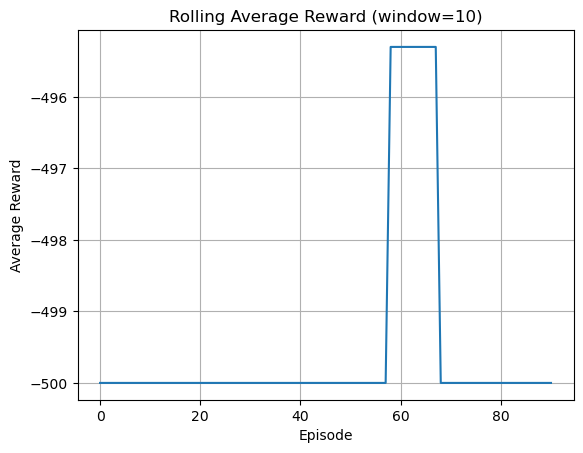

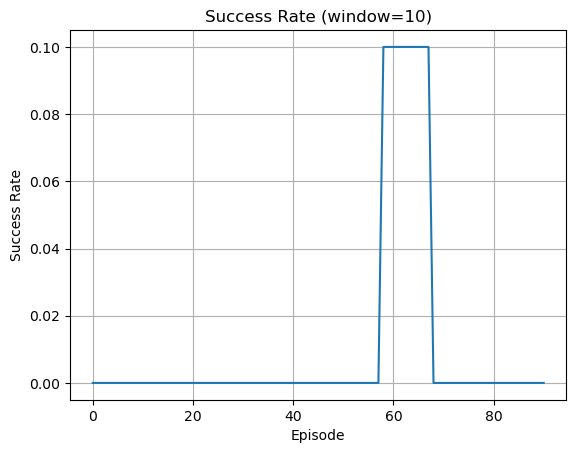

In [ ]:
random_rewards, random_episode_lengths = run_agent(env, random_ag, num_episodes=100, print_every=10)
gif_episode(env, random_ag, filename="random_agent_episode.gif")
plot_rewards(random_rewards)
plot_success(random_rewards)


### Part 2.2: Q-Learning with state discretization

Complete the tasks described in the project description and answer the following questions:

**Questions:**
1. For a given number of bins per dimension $n$, how many discrete states are there in total? How does this scale with the state dimension $d$?
2. What are the trade-offs of using a small number of bins? What are the trade-offs of using a large number of bins?
3. On average, which agent (random or Q-learning) will first reach the target height? Would this change with a different value of $\varepsilon$, a different Q-value initialization or a different reward function? Justify.
4. Does the Q-learning agent improve its performance over time? Does it manage to reach the goal in every episode eventually? Why or why not?
5. How does performance depend on n_bins? Which value gives the best results on this environment?

**Your answers here**
1. If you were to discretize a 1D state space you would get (length of space)/(length of bins) = n total discrete states. If you do the same in 2D you would get that nbr of states in each dimension, which would mean n^2 in total. This means the state space scales exponentially with the number of dimensions.
2. Using a small number of bins means the state space is small, which means the Q-table requires very little memory. The agent is also able to visit all states faster which means learning converges faster. However, few bins means the bins are large, that can lead to physically different scenarios fall into the same bin, which then means the agent cannot distingush between them. This can result in the agent failing to learn a good policy because one bin requires different actions. 

On the other hand, if you have a large number of bins, you get high presicion. The agent can distingush small differences in the environment, which allows it to learn complex, optimal policies. However, this causes the state space to become massive, so the agent will need more training episodes to explore the full space and propagate the Q-values. Otherwise the states will remain unvisited, their Q-values will be stuck at 0 and the agent will perform badly.

3. On average, the Q-learning agent will reach the target height first. THis is because how the reward system is set up and how the Q-table is initilized. Since the agent recieves a reward of $-1$ for each step it doesn't reach the goal and the Q-table is initilized to $0$, untried actions have a higher value ($0$) than tried actions (will become negative). This creates an accidental optimistic initialization which drives the agent to explore new states rather than wandering aimlessly like the random agent.

This can change with different parameter choices. If you were to choose $\varepsilon=1$ the Q-learning agent would exactly become the random agent. Or if $\varepsilon$ is too low and initialization is not optimistic, it might use bad initial paths and get stuck in a loop, taking much longer to find the goal than a random walk. If you initialized the Q-values pessimistically (e.g., to -100), the agent would aggressively stick to the very first sequence of actions it tried, severely delaying the initial discovery of the goal. Also, a "dense" reward function (e.g., giving small positive rewards for moving closer to the target height) would guide the Q-learning agent to the goal dramatically faster than a random agent.

4. Yes. Over time, the temporal difference update rule propagates the positive rewards backward from the goal state to the starting states. This causes the agent to learn the optimal sequence of actions to maximize return. However, it might stil not reach the goal in every eposide. The first reason for this is that we use the $\varepsilon$ greedy policy. As long as $\varepsilon>0$ we always have a small posibility of the agent choosing a random action and not the optimal one, even if it knows the optimal choice. Since we are in a quite unstaple physical environment, a single random action at the wrong time may cause the agent to loose its momentum, causing it to fail or timeout in that episode. Another reason is discretazation limits. If $n$ is n ot perfectly tuned, there will always be small inaccuracies when going from a continuous to a discrete state space representation. This can lead to occasional mistakes. 

5. Performence depends on n_bins not being to low or to high. If n_bins is too low, the agent cannot learn the physics of the environment due to state aliasing and fails constantly. If n_bins is too high, the number of training episodes are too low for the agent to explore all the states, resulting in a sparse Q-table and bad performance. In this test case, using 100 episodes, n_bins$=10$ performed the best. REDO WITH MORE EPISODES???

In [7]:
class StateDiscretizer:
    def __init__(self, env, n_bins):
        self.lower_bound, self.upper_bound = env.state_space
        self.n_bins = n_bins
        # your code here

        self.bin_widths = (self.upper_bound - self.lower_bound) / self.n_bins
    
    def __call__(self, state):
        # your code here
        # Shift the state to start at 0 then divide by width
        discretized = (state - self.lower_bound)/self.bin_widths

        # take floor to get the integer bin index
        discretized = np.floor(discretized).astype(int)

        # Edge case: if a state exactly hits the upper bound, 
        # it might calculate an index of n_bins, which is out of bounds (max index is n_bins - 1).
        # We clip the values to ensure they stay strictly within [0, n_bins - 1].
        discretized = np.clip(discretized, 0, self.n_bins - 1)

        # Return as a tuple so it can be used as a dictionary key in Q-learning
        return tuple(discretized)

# test the discretizer
state = env.reset()
discretizer = StateDiscretizer(env, n_bins=10)
discretized_state = discretizer(state)
print("Original state:", state)
print("Discretized state:", discretized_state)

Original state: (0.9981099367141724, 0.06145411357283592, 0.9950762987136841, -0.0991118997335434, -0.06194114685058594, -0.05898217856884003)
Discretized state: (np.int64(9), np.int64(5), np.int64(9), np.int64(4), np.int64(4), np.int64(4))


In [ ]:
class QLearningAgent(AbstractAgent):
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, n_bins=10):
        super().__init__(env)
        self.n_actions = env.n_actions
        self.discretizer = StateDiscretizer(env, n_bins)
        self.Q = defaultdict(lambda: np.zeros(self.n_actions)) # you can use a different data structure if you prefer
        # your code here

        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def observe(self, state, action, reward, next_state, done):
        # your code here
        # Discretize continuous states into discrete tuples
        s = self.discretizer(state)
        s_prime = self.discretizer(next_state)

        # If the episode is done, there are no future rewards
        if done:
            target = reward
        else:
            # max_{a'} Q(s', a')
            best_next_q = np.max(self.Q[s_prime])
            target = reward + self.gamma * best_next_q
        
        # Update rule: Q(s,a) <- Q(s,a) + alpha * [target - Q(s,a)]
        td_error = target - self.Q[s][action]
        self.Q[s][action] += self.alpha * td_error

    def act(self, state):
        # your code here
        s = self.discretizer(state)

        # Epsilon-greedy strategy
        if random.random() < self.epsilon:
            # Explore: choose a random action
            return random.choice(self.env.available())
        else:
            # Exploit: choose the best action
            q_values = self.Q[s]
            max_q = np.max(q_values)
            
            # Break Q-value ties randomly
            # Find all indices (actions) that have the maximum Q-value
            best_actions = [a for a, q in enumerate(q_values) if q == max_q]            
            # Randomly select one of the best actions
            return random.choice(best_actions)
    
# Analyze the Q-learning agent
Q_learning_ag = QLearningAgent(env)


In [ ]:
# Test just Q-learning
Q_rewards, Q_episode_lengths = run_agent(env, Q_learning_ag, num_episodes=100, print_every=10)
gif_episode(env, Q_learning_ag, filename="Q_learning_agent_episode.gif")
plot_rewards(Q_rewards)
plot_success(Q_rewards)

Running Random Agent...
Running Q-Learning Agent (n_bins=5)...
Running Q-Learning Agent (n_bins=10)...
Running Q-Learning Agent (n_bins=20)...


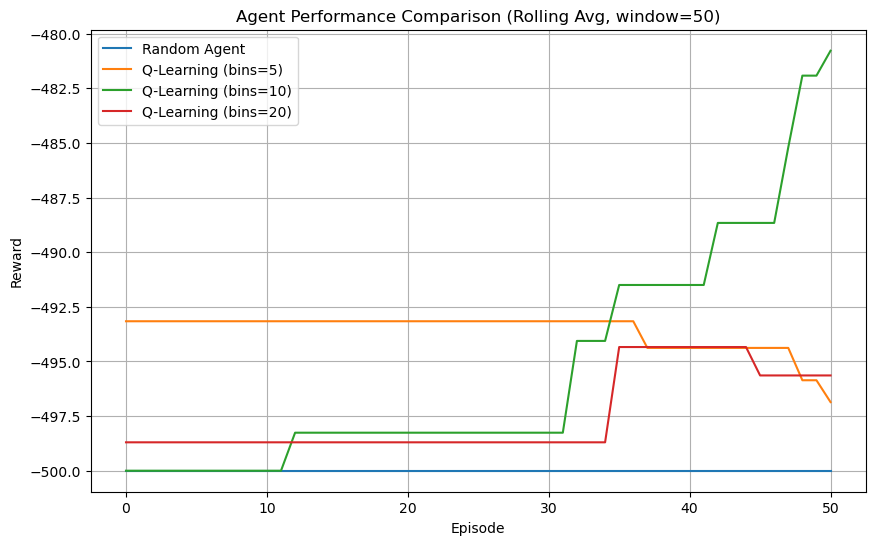

In [15]:
# Comparison with RandomAgent
experiment_results = {}

# --- Experiment Setup ---
num_episodes = 100  
window_size = 50

print("Running Random Agent...")
rand_rewards, _ = run_agent(env, random_ag, num_episodes)
experiment_results['Random Agent'] = rand_rewards

# 3. Run Q-Learning agents with different bin sizes
bins_to_test = [5, 10, 20] 

for n_bins in bins_to_test:
    print(f"Running Q-Learning Agent (n_bins={n_bins})...")
    
    # Initialize a fresh agent for each bin configuration
    agent = QLearningAgent(env, n_bins=n_bins)
    
    # Train the agent
    rewards, _ = run_agent(env, agent, num_episodes)
    
    # Store the results
    experiment_results[f'Q-Learning (bins={n_bins})'] = rewards

# 4. Plot the performance
plt.figure(figsize=(10, 6))

for label, rewards in experiment_results.items():
    # Convert to numpy array and calculate the rolling average 
    # to make the trends easier to read
    rewards_arr = np.array(rewards)
    rolling_avg = np.convolve(
        rewards_arr, 
        np.ones(window_size) / window_size, 
        mode='valid'
    )
    plt.plot(rolling_avg, label=label)

plt.title(f"Agent Performance Comparison (Rolling Avg, window={window_size})")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()

### Part 2.3: Q-Learning with state discretization

Complete the tasks described in the project description and answer the following questions:

**Questions:**
1. Derive the partial derivative of $\mathcal{L}(w) = \frac{1}{2}\delta^2$ with respect to $w_{a,j}$, treating the target as a constant. Show your calculations and state the resulting update rule.
2. After observing a transition $(s_t,a_t,r_t,s_{t+1})$, which of the weights $w_{a,j}$ get updated and which stay unchanged?
3. What would differ between the bin-based Q-learning agent and the RBF agent in their treatment of a previously unseen state?
4. Does the RBF agent improve over time? Does it reach the goal consistently? Why or why not?
5. How does performance depend on n_centers_per_dim and $\alpha$? Which combination yields the best results?

**Your answers here**
1. We have 
$$Q(s, a | w) = \sum_{i} w_{a,i} \phi_i(s)$$
The TD error os the target (constant) minus this Q-value prediction: 
$$\delta = Target - \sum_{i} w_{a,i} \phi_i(s)$$
Using the chain rule we can find the partial derivative of the loss function $\mathcal{L}(w) = \frac{1}{2}\delta^2$ with respect to the specific weight $w_{a,j}$
$$\frac{\partial \mathcal{L}(w)}{\partial w_{a,j}} = \frac{1}{2} \cdot 2\delta \cdot \frac{\partial \delta}{\partial w_{a,j}}$$
$$\frac{\partial \mathcal{L}(w)}{\partial w_{a,j}} = \delta \frac{\partial \delta}{\partial w_{a,j}}$$
Now find the partial derivative of $\delta$ with respect to $w_{a,j}$. Using that the target is constant (semi-gradient method), we get
$$\frac{\partial \delta}{\partial w_{a,j}} = \frac{\partial}{\partial w_{a,j}} \left[ Target - \sum_{i} w_{a,i} \phi_i(s) \right]$$
$$\frac{\partial \delta}{\partial w_{a,j}} = -\phi_j(s)$$
Substitute back into $\mathcal{L}$:
$$\frac{\partial \mathcal{L}(w)}{\partial w_{a,j}} = \delta (-\phi_j(s))$$
$$\frac{\partial \mathcal{L}(w)}{\partial w_{a,j}} = -\delta \phi_j(s)$$
Which results in the update rule
$$w_{a,j} \leftarrow w_{a,j} + \alpha \delta \phi_j(s)$$
2. When the agent observes a transition, the weights are updated based on two main things: the action taken and the distance to the current state. The weights for any action that was not taken are ignored and unchanged and even for the action that was taken, weights connected to RBF centers located far away from the current state remains effectively unchanged. The feature value $\phi_j(s_t)$ for states far away is approximately $0$, which causes their updates to also be $\approx 0$. Only the weights belonging to the action taken (that are close enough to the current state) receives an update. The size of this update depends on how close the RBF center is to the current state. Centers that are physically close to the state have a high activation value $\phi_j(s_t)$, so their corresponding weights receive a significant update to reflect the newly learned information.
3. For the bin nased agent: If the agent encounters a totally new state that falls into a bin it has never visited, it looks at its Q-table, sees a value of 0.0, and acts completely blindly. It cannot transfer knowledge from neighboring bins. It has to learn every single bin from scratch.
For the RBF agent: RBFs act like overlapping fields of influence. if the agent visits a new state, it doesn't just look at one isolated bin. Instead, the new state activates several nearby RBF centers. If the agent has previously learned good weights for those nearby centers, the formula $Q(s,a) = \sum w \cdot \phi(s)$ will smoothly "blend" those nearby weights to guess a highly accurate Q-value for the unseen state. It learns what to do based on similar past experiences.
4. Yes. Just like the discrete agent, the TD error forces the weights to adjust so the predicted Q-values match the true expected returns. Because it can generalize, the RBF agent can learn a good policy in fewer episodes than a high-resolution bin agent.
It seems more consistent than the bin agent once trained, in our test cases it reaches $100\%$ accuracy after only about $30$ episodes, which is a clear improvement compared to the bin agent. However, this is not a mathematical guarantee. It still uses $\varepsilon$ greedy exploration, which causes it to take random actions at some probability. Also, function approximation is sensitive to learning rate. If the learning rate is too high, the overlapping nature of RBFs means an update in one area might accidentally overwrite or distort a good policy in a neighboring area, causing performance dips.
5. n_centers_per_dim: This works similarly to the bins. Too few centers means the agent's RBFs are too wide and blurry (underfitting). It can't learn the precise physics. Too many centers means the fields of influence are incredibly narrow, destroying the generalization benefit and slows down learning.
$\alpha$: In function approximation, multiple weights are updated at once. If the learning rate is too high, aa single large reward will drastically increase the weights, which can cause instability in the overlapping neighbors. The agent will oscillate wildly and fail to learn. If $\alpha$ is too low, it learns too slowly to converge within the episode limit.
In the most recent test the best combinations are 3 centers with $\alpha = 0.01$ and 5 centers with $\alpha = 0.1$, as they provide the optimal balance of broad state generalization and stable, confident weight updates.

MAYBE REDO TEST WITH MORE EPISODES?

In [6]:
def rbf_features(state, centers, sigma):
    """
    Compute the RBF features for a given state, given the centers and sigma.
    Arguments:
        - state: the input state, a vector of shape (state_dim,)
        - centers: a np array of shape (n_centers, state_dim)
        - sigma: a vector of shape (state_dim,)
    """
    # your code here
    # 1. Calculate the scaled squared differences
    scaled_sq_diff = ((state - centers) ** 2) / (2 * sigma ** 2)

    # 2. Sum across the state dimensions (axis=1)
    summed_diff = np.sum(scaled_sq_diff, axis=1)

    # 3. Apply the exponential
    phi = np.exp(-summed_diff)

    return phi

class RBFAgent(AbstractAgent):
    """
    Agent using Radial Basis Function (RBF) features to approximate the Q-function.
    """
    def __init__(self, env: Acrobot, alpha: float = 0.1, gamma: float = 0.9, epsilon_exploration: float = 0.1, n_centers_per_dim: int = 5):
        super().__init__(env)
        # your code here
        self.n_actions = env.n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_exploration

        # Unpack state boundaries
        lower_bounds, upper_bounds = env.state_space
        state_dim = len(lower_bounds)

        # Construct grid of centers and sigmas
        grids = []
        spacings = []

        for d in range(state_dim):
            # Create centers along this specific dimension
            dim_centers = np.linspace(lower_bounds[d], upper_bounds[d], n_centers_per_dim)
            grids.append(dim_centers)
            
            # Calculate the spacing between adjacent centers
            spacing = (upper_bounds[d] - lower_bounds[d]) / (n_centers_per_dim - 1)
            spacings.append(spacing)
        

        # Combine 1D grids into a full N-dimensional grid
        mesh = np.meshgrid(*grids, indexing='ij')
        
        # Flatten the meshgrid to get an array of shape (Total Centers, State Dimension)
        self.centers = np.stack([m.flatten() for m in mesh], axis=-1)
        
        # Set sigmas to half the spacing
        self.sigmas = np.array(spacings) / 2.0
        
        # Initialize weights
        # We need a weight for every feature (center), for every action.
        n_centers_total = self.centers.shape[0]
        self.Q_weights = np.zeros((self.n_actions, n_centers_total))
        
    def _get_q_values(self, state):
        """Helper method to compute Q(s,a) for all actions given a state."""
        phi = rbf_features(state, self.centers, self.sigmas)
        # Matrix multiplication: shape (n_actions, n_centers) @ (n_centers,) -> (n_actions,)
        return self.Q_weights @ phi

    def observe(self, state: int, action: int, reward: float, next_state: int, done: bool):
        # your code here
        # Get the feature representation of the current state
        phi_s = rbf_features(state, self.centers, self.sigmas)

        # Calculate the current Q-value prediction
        q_s_a= np.dot(self.Q_weights[action], phi_s)

        # Calculate TD target
        if done:
            target = reward
        else:
            q_next = self._get_q_values(next_state)
            target = reward + self.gamma * np.max(q_next)

        # Calculate TD error
        delta = target - q_s_a

        # Apply semi-gradiens update rule
        self.Q_weights[action] += self.alpha * delta * phi_s

    def act(self, state: int) -> int:
        # your code here
        # Epsilon-greedy strategy
        if random.random() < self.epsilon:
            return random.choice(self.env.available())
        else:
            q_values = self._get_q_values(state)
            max_q = np.max(q_values)
            
            # Break ties randomly
            best_actions = [a for a, q in enumerate(q_values) if q == max_q]
            return random.choice(best_actions)
    
# Analyze the RBF agent
RBF_ag = RBFAgent(env)

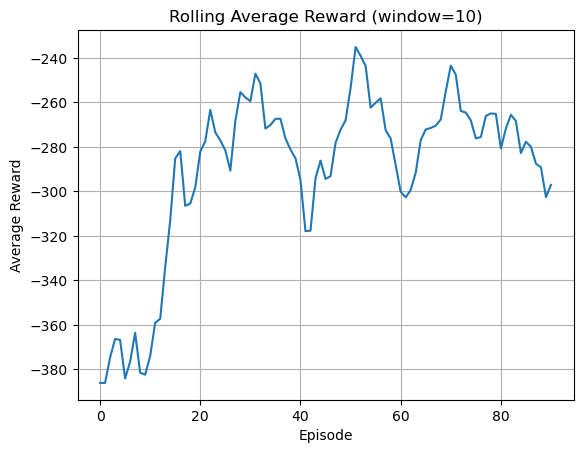

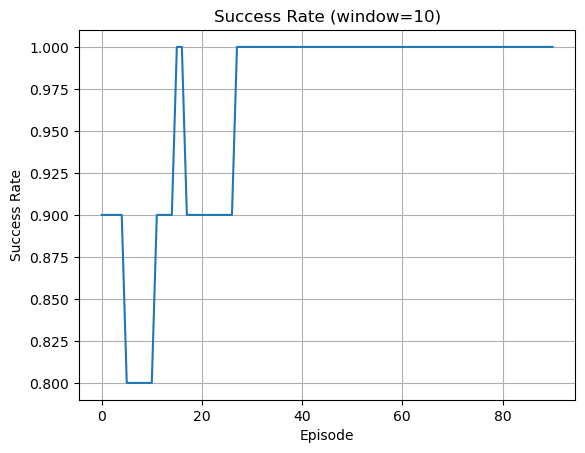

In [7]:
# Test just RBF
RBF_rewards, RBF_episode_lengths = run_agent(env, RBF_ag, num_episodes=100, print_every=10)
gif_episode(env, RBF_ag, filename="RBF_agent_episode.gif")
plot_rewards(RBF_rewards)
plot_success(RBF_rewards)

Starting RBF Agent Hyperparameter Search...
Running: Centers: 3, Alpha: 0.01...
Running: Centers: 3, Alpha: 0.1...
Running: Centers: 3, Alpha: 0.5...
Running: Centers: 5, Alpha: 0.01...
Running: Centers: 5, Alpha: 0.1...
Running: Centers: 5, Alpha: 0.5...
Running: Centers: 7, Alpha: 0.01...
Running: Centers: 7, Alpha: 0.1...
Running: Centers: 7, Alpha: 0.5...
Training complete! Generating plot...


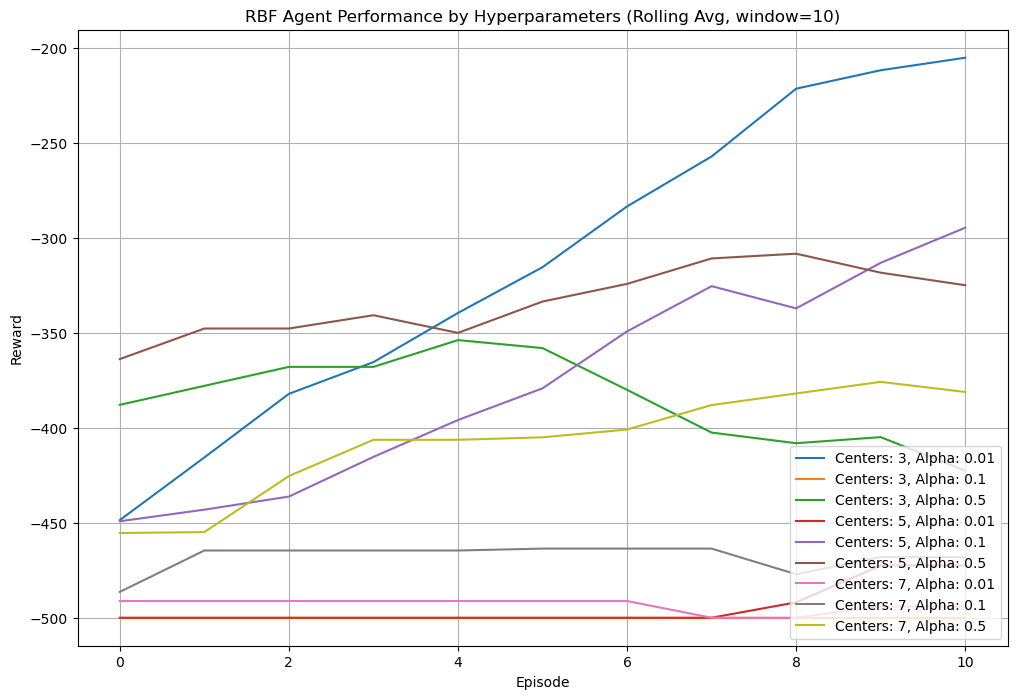

In [11]:
# --- Experiment Setup ---
num_episodes = 20  # Adjust if needed based on your environment
window_size = 10    # Smoothing window for the rolling average

# Define the hyperparameters to test
centers_to_test = [3, 5, 7]
alphas_to_test = [0.01, 0.1, 0.5]

# Dictionary to store the reward history for each combination
rbf_experiment_results = {}

print("Starting RBF Agent Hyperparameter Search...")

# Loop through every combination of centers and alpha
for n_centers in centers_to_test:
    for alpha in alphas_to_test:
        label = f"Centers: {n_centers}, Alpha: {alpha}"
        print(f"Running: {label}...")
        
        # Initialize a fresh agent for this specific combination
        agent = RBFAgent(env, alpha=alpha, n_centers_per_dim=n_centers)
        
        # Train the agent
        rewards, _ = run_agent(env, agent, num_episodes)
        
        # Store the results using the combination label as the key
        rbf_experiment_results[label] = rewards

print("Training complete! Generating plot...")

# --- Plotting the performance ---
plt.figure(figsize=(12, 8))

for label, rewards in rbf_experiment_results.items():
    # Convert to numpy array and calculate the rolling average
    rewards_arr = np.array(rewards)
    rolling_avg = np.convolve(
        rewards_arr, 
        np.ones(window_size) / window_size, 
        mode='valid'
    )
    # Plot each line
    plt.plot(rolling_avg, label=label)

plt.title(f"RBF Agent Performance by Hyperparameters (Rolling Avg, window={window_size})")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Part 3: Policy gradient

### part 3.1: REINFORCE with a linear softmax policy

Complete the tasks described in the project description and answer the following questions:

**Questions:**
1. What gradient expression did you derive? Show your calculations.
2. What are the main differences between REINFORCE and Q-learning with RBFs in terms of (i) what they learn, (ii) how they update, and (iii) the kind of policy they produce?
3. Could we use an $\varepsilon$-greedy policy with REINFORCE? Why or why not?
4. Does the agent improve over time? Comment on your plots.

**Your answers here**
1. ...
2. ...
3. ...
4. ...

In [ ]:
class REINFORCEAgent(AbstractAgent):
    def __init__(self, env: Acrobot, alpha: float = 0.1, gamma: float = 0.9, n_centers_per_dim: int = 5):
        super().__init__(env)
        # your code here
        self.centers = ...
        self.sigmas = ...
        self.policy_weights = ...
        self.episode_memory = []  # to store (state, action, reward) for the current episode


    def observe(self, state: int, action: int, reward: float, next_state: int, done: bool):
        # your code here
        raise NotImplementedError

    def act(self, state: int) -> int:
        # your code here
        raise NotImplementedError

# Analyze the REINFORCE agent
# ...

### part 3.2: REINFORCE with a Multi-Layer Perceptron (MLP)

Complete the tasks described in the project description and answer the following questions:

**Questions:**
1. Compared to the linear softmax policy, what has changed architecturally, and why does this make the policy more expressive?
2. Compare the performance of linear and MLP REINFORCE agents. Is there a significant improvement?
3. For which value of the learning rate do you find the best results?

**Your answers here**
1. ...
2. ...
3. ...

In [ ]:
# use pytorch to implement a MLP policy network and train it with REINFORCE
class REINFORCEAgentMLP(AbstractAgent):
    def __init__(self, env: Acrobot, alpha: float = 0.1, gamma: float = 0.9, hidden_size: int = 64):
        super().__init__(env)
        
        # your code here

        self.n_actions = env.n_actions
        self.state_dim = env.state_dim
        # simple MLP with one hidden layer
        self.policy_mlp = torch.nn.Sequential(
            torch.nn.Linear(self.state_dim, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, self.n_actions)
        )
        self.optimizer = torch.optim.Adam(self.policy_mlp.parameters(), lr=self.alpha)
        self.episode_memory = []  # to store (state, action, reward) for the current episode

    def _compute_probs(self, state):
        """
        
        """
        state_tensor = torch.FloatTensor(state)
        logits = self.policy_mlp(state_tensor)
        exp_logits = torch.exp(logits - torch.max(logits))  # for numerical stability
        probs = exp_logits / (torch.sum(exp_logits) + 1e-8)  # add small value to avoid division by zero
        return probs
    
    def _compute_loss_term(self, state, action, G):
        probs = self._compute_probs(state)
        log_prob = torch.log(probs[action])
        return -log_prob * G
    
    def _update_parameters(self, sum_of_loss_terms):
        self.optimizer.zero_grad()
        sum_of_loss_terms.backward()
        self.optimizer.step()
    

    def act(self, state):
        # your code here (use _compute_probs)
        raise NotImplementedError

    
    def observe(self, state, action, reward, next_state, done):
        # your code here
        # hint: compute G for each loss term, then use _compute_loss_term and _update_parameters
        raise NotImplementedError



## part 4: Actor-Critic

Complete the tasks described in the project description and answer the following questions:

**Questions:**
1. 
2. 
3. 

**Your answers here**
1. ...
2. ...
3. ...

In [ ]:
class ActorCriticAgent(AbstractAgent):
    def __init__(self, env: Acrobot, alpha_actor: float = 0.1, alpha_critic: float = 0.1, gamma: float = 0.9, hidden_size: int = 64):
        super().__init__(env)
        # your code here

        self.n_actions = env.n_actions
        self.state_dim = env.state_dim
        # simple MLP for the policy (actor)
        self.policy_mlp = torch.nn.Sequential(
            torch.nn.Linear(self.state_dim, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, self.n_actions)
        )
        # simple MLP for the value function (critic)
        self.value_mlp = torch.nn.Sequential(
            torch.nn.Linear(self.state_dim, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, 1)
        )
        self.optimizer_actor = torch.optim.Adam(self.policy_mlp.parameters(), lr=alpha_actor)
        self.optimizer_critic = torch.optim.Adam(self.value_mlp.parameters(), lr=alpha_critic)
        self.episode_memory = []  # to store (state, action, reward) for the current episode


    def _compute_probs(self, state):
        state_tensor = torch.FloatTensor(state)
        logits = self.policy_mlp(state_tensor)
        exp_logits = torch.exp(logits - torch.max(logits))  # for numerical stability
        probs = exp_logits / torch.sum(exp_logits) + 1e-8  # add small value to avoid division by zero
        return probs
    
    def _compute_value(self, state):
        state_tensor = torch.FloatTensor(state)
        value = self.value_mlp(state_tensor)
        return value.squeeze()  # remove extra dimension
    
    def _compute_advantage(self, state, reward, next_state, done):
        # your code here (compute advantage using the critic)
        # hint: use _compute_value
        raise NotImplementedError
    
    def _compute_actor_loss(self, state, action, reward, next_state, done):
        with torch.no_grad():
            advantage = self._compute_advantage(state, reward, next_state, done)
        probs = self._compute_probs(state)
        log_prob = torch.log(probs[action])

        return -log_prob * advantage
    
    def _compute_critic_loss(self, state, reward, next_state, done):
        advantage = self._compute_advantage(state, reward, next_state, done)
        return advantage.pow(2)  # MSE loss for the critic
    
    def _update_parameters(self, actor_loss, critic_loss):
        # update actor
        self.optimizer_actor.zero_grad()
        actor_loss.backward()
        self.optimizer_actor.step()
        # update critic
        self.optimizer_critic.zero_grad()
        critic_loss.backward()
        self.optimizer_critic.step()

    def act(self, state):
        # your code here (use _compute_probs)
        raise NotImplementedError
    
    def observe(self, state, action, reward, next_state, done):
        # your code here
        # hint: compute advantage, then compute actor and critic loss, then update parameters
        raise NotImplementedError
